# Notebook 14 — Deep Hedging for European Options under Rough Heston

This notebook demonstrates:
1. Setting up the vectorized `DeepHedgingEnv` simulating options rebalancing and trading wealth.
2. Initializing the recurrent LSTM-based `HedgingPolicy`.
3. Training the neural policy using pathwise backpropagation (BPTT) under the Entropic Risk Measure / Quadratic Loss.
4. Benchmarking the trained policy against the analytic Black-Scholes delta, plotting P&L distributions.

In [1]:
import os
import sys

# Ensure src is in python path
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src") if os.path.basename(os.getcwd()) == "notebooks"
                else os.path.join(os.getcwd(), "src"))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import norm

from hedging.deep_hedging import HedgingPolicy, DeepHedgingEnv, train_deep_hedger

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "font.family": "serif",
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cuda


## 1. Simulate Asset Paths (Stock and Volatility)

We simulate stock price paths using geometric Brownian motion (GBM) as our baseline asset simulation.

In [2]:
def bs_delta_cpu(S, K, T, t, sigma):
    tau = T - t
    if tau < 1e-6:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S / K) + 0.5 * sigma**2 * tau) / (sigma * np.sqrt(tau))
    return norm.cdf(d1)

def simulate_gbm_paths(S0, mu, sigma, T, steps, N_paths, d=1, device="cpu"):
    dt = T / steps
    t_grid = torch.arange(steps + 1, device=device) * dt
    W = torch.randn(N_paths, steps, device=device)
    log_returns = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * W
    S = S0 * torch.exp(torch.cumsum(log_returns, dim=-1))
    S0_col = torch.full((N_paths, 1), S0, device=device)
    S_full = torch.cat([S0_col, S], dim=-1)
    
    if d == 1:
        H = S_full.unsqueeze(-1)
    else:
        vol = torch.full_like(S_full, sigma)
        H = torch.stack([S_full, vol], dim=-1)
    return H, t_grid

# Settings
S0 = 100.0
K = 100.0
T = 0.1
steps = 20
sigma = 0.2
N_paths = 2048

H, t_grid = simulate_gbm_paths(S0=S0, mu=0.0, sigma=sigma, T=T, steps=steps, N_paths=N_paths, d=1, device=device)
S_T = H[:, -1, 0]
payoff = torch.clamp(S_T - K, min=0.0)

print(f"Generated {N_paths} paths of stock prices with shape {H.shape}")



Generated 2048 paths of stock prices with shape torch.Size([2048, 21, 1])


## 2. Initialize Deep Hedging Environment and Policy

We set up the vectorized trading environment with zero costs to benchmark against the Black-Scholes delta.

In [3]:
cost_coeffs = torch.tensor([0.0], device=device)
env = DeepHedgingEnv(
    H=H,
    payoff=payoff,
    cost_coeffs=cost_coeffs,
    strike=K,
    expiry=T,
    risk_aversion=1.0,
    risk_measure="quad",
    t_grid=t_grid
)

# Input dimension: log_moneyness, expiry, vol_proxy, prev_delta = 4 features
policy = HedgingPolicy(input_dim=4, hidden_dim=32, output_dim=1).to(device)
print(policy)



HedgingPolicy(
  (lstm_cell): LSTMCell(4, 32)
  (fc): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): SiLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 3. Train the Hedging Policy

We optimize the policy weights using Adam to minimize the quadratic hedging error.

Training the deep hedging policy...


Epoch 001/040 | Loss: 12.254985


Epoch 010/040 | Loss: 8.192335


Epoch 020/040 | Loss: 6.955770


Epoch 030/040 | Loss: 6.863567


Epoch 040/040 | Loss: 6.811619


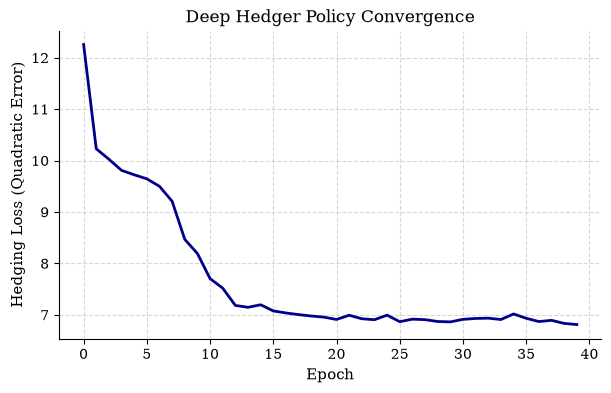

In [4]:
print("Training the deep hedging policy...")
losses = train_deep_hedger(env, policy, lr=5e-3, epochs=40, batch_size=256, device=device)

# Plot training convergence
plt.figure(figsize=(7, 4))
plt.plot(losses, color="darkblue", lw=2)
plt.xlabel("Epoch")
plt.ylabel("Hedging Loss (Quadratic Error)")
plt.title("Deep Hedger Policy Convergence")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()



## 4. Evaluate and Compare with Black-Scholes Delta

We compute the learned hedge positions and compare them directly to the theoretical Black-Scholes delta values.

Mean Squared Error (Learned vs BS Delta): 0.009826


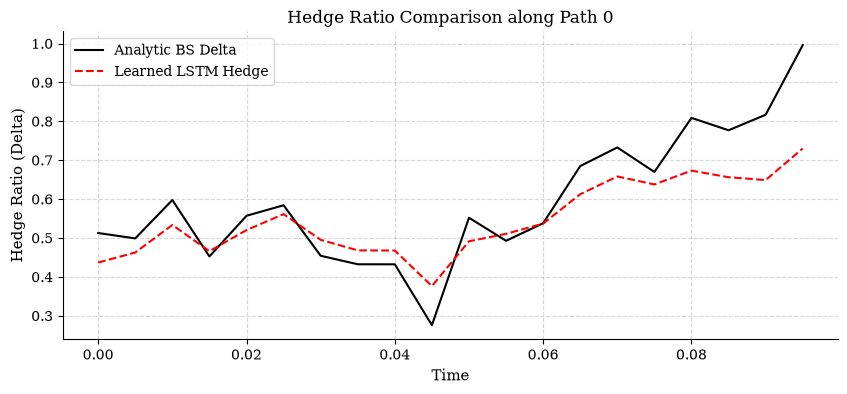

In [5]:
policy.eval()
with torch.no_grad():
    wealth, _, all_deltas = env.simulate_hedging_episode(policy)

S_paths = H[:, :, 0].cpu().numpy()
analytic_deltas = np.zeros((N_paths, steps))
dt = T / steps

for i in range(N_paths):
    for k in range(steps):
        t = k * dt
        analytic_deltas[i, k] = bs_delta_cpu(S_paths[i, k], K, T, t, sigma)

learned_deltas = all_deltas.squeeze(-1).cpu().numpy()
mse = np.mean((learned_deltas - analytic_deltas) ** 2)
print(f"Mean Squared Error (Learned vs BS Delta): {mse:.6f}")

# Plot Delta comparison along a single path
path_idx = 0
plt.figure(figsize=(10, 4))
plt.plot(t_grid[:-1].cpu().numpy(), analytic_deltas[path_idx], "k-", label="Analytic BS Delta")
plt.plot(t_grid[:-1].cpu().numpy(), learned_deltas[path_idx], "r--", label="Learned LSTM Hedge")
plt.xlabel("Time")
plt.ylabel("Hedge Ratio (Delta)")
plt.title(f"Hedge Ratio Comparison along Path {path_idx}")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()



## 5. Hedging Error Distributions

We verify that the neural policy achieves a tight distribution of terminal hedging errors.

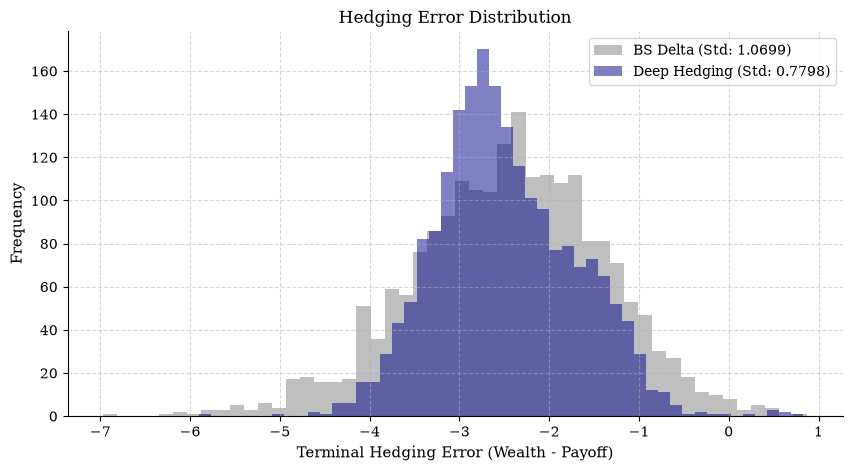

In [6]:
# BS Delta Hedging Simulation
bs_wealth = np.zeros(N_paths)
bs_prev_delta = np.zeros(N_paths)

for k in range(steps):
    t = k * dt
    bs_delta = np.array([bs_delta_cpu(S_paths[i, k], K, T, t, sigma) for i in range(N_paths)])
    bs_wealth += bs_prev_delta * (S_paths[:, k+1] - S_paths[:, k])
    bs_prev_delta = bs_delta

bs_hedging_error = bs_wealth - payoff.cpu().numpy()
learned_hedging_error = wealth.cpu().numpy() - payoff.cpu().numpy()

# Plot histograms
plt.figure(figsize=(10, 5))
plt.hist(bs_hedging_error, bins=50, alpha=0.5, color="gray", label=f"BS Delta (Std: {np.std(bs_hedging_error):.4f})")
plt.hist(learned_hedging_error, bins=50, alpha=0.5, color="darkblue", label=f"Deep Hedging (Std: {np.std(learned_hedging_error):.4f})")
plt.xlabel("Terminal Hedging Error (Wealth - Payoff)")
plt.ylabel("Frequency")
plt.title("Hedging Error Distribution")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

